<a href="https://colab.research.google.com/github/planket01/2026_DL/blob/main/chapter02_0916.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [ ]:
!pip install keras keras-hub --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.31.1 which is incompatible.


In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [2]:
# @title
# 선택하신 코드는 사용자 정의 IPython 셀 매직인 %%backend를 정의합니다.
#이 매직 함수는 KERAS_BACKEND 환경 변수의 현재 값에 따라 특정 코드 셀의
#실행을 제어합니다. 예를 들어, 셀이 %%backend tensorflow로 시작하면
#KERAS_BACKEND가 'tensorflow'로 설정된 경우에만 해당 셀의 코드를 실행합니다.
#그렇지 않으면, 필요한 백엔드를 설정하고 런타임을
#다시 시작하라는 메시지를 출력합니다.
#이는 특정 Keras 백엔드(예: TensorFlow, JAX, PyTorch)가 필요하거나
#다르게 동작하는 코드 블록을 관리하는 데 유용합니다
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## The mathematical building blocks of neural networks

### A first look at a neural network

In [3]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
train_images.shape

(60000, 28, 28)

In [5]:
len(train_labels)

60000

In [6]:
train_labels

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [7]:
test_images.shape

(10000, 28, 28)

In [8]:
len(test_labels)

10000

In [9]:
test_labels

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [10]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [12]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

In [13]:
model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9257 - loss: 0.2635
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9688 - loss: 0.1057
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9798 - loss: 0.0686
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9858 - loss: 0.0494
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9891 - loss: 0.0374


In [14]:
test_digits = test_images[0:10]
predictions = model.predict(test_digits)
predictions[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step


array([5.3396448e-06, 3.4834912e-08, 3.9294373e-05, 7.5659476e-04,
       2.0694297e-09, 2.9815450e-07, 3.9217917e-11, 9.9914384e-01,
       8.4091607e-06, 4.6123310e-05], dtype=float32)

In [15]:
predictions[0].argmax()

np.int64(7)

In [16]:
predictions[0][7]

np.float32(0.99914384)

In [17]:
test_labels[0]

np.uint8(7)

In [18]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"test_acc: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9741 - loss: 0.0780
test_acc: 0.9740999937057495


### Data representations for neural networks

#### Scalars (rank-0 tensors)

In [19]:
import numpy as np
x = np.array(12)
x

array(12)

In [20]:
x.ndim

0

#### Vectors (rank-1 tensors)

In [21]:
x = np.array([12, 3, 6, 14, 7])
x

array([12,  3,  6, 14,  7])

In [22]:
x.ndim

1

#### Matrices (rank-2 tensors)

In [23]:
x = np.array([[5, 78, 2, 34, 0],
              [6, 79, 3, 35, 1],
              [7, 80, 4, 36, 2]])
x.ndim

2

#### Rank-3 tensors and higher-rank tensors

In [24]:
x = np.array([[[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]],
              [[5, 78, 2, 34, 0],
               [6, 79, 3, 35, 1],
               [7, 80, 4, 36, 2]]])
x.ndim

3

#### Key attributes

In [25]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [26]:
train_images.ndim

3

In [27]:
train_images.shape #dim=3인 것을 shape를 통해 알 수 있다.

(60000, 28, 28)

In [28]:
train_images.dtype

dtype('uint8')

In [29]:
train_images[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

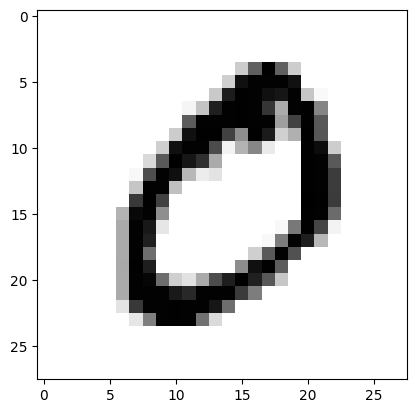

In [30]:
import matplotlib.pyplot as plt

digit = train_images[1]
plt.imshow(digit, cmap=plt.cm.binary)
plt.show()

In [31]:
train_labels[4]

np.uint8(9)

#### Manipulating tensors in NumPy

In [32]:
my_slice = train_images[10:100]
my_slice.shape

(90, 28, 28)

In [33]:
my_slice = train_images[10:100, :, :]
my_slice.shape

(90, 28, 28)

In [34]:
my_slice = train_images[10:100, 0:28, 0:28]
my_slice.shape

(90, 28, 28)

In [35]:
my_slice = train_images[:, 14:, 14:]

In [36]:
my_slice = train_images[:, 7:-7, 7:-7]

#### The notion of data batches

In [37]:
batch = train_images[:100] # 100개를 뽑아라? << 원래 128개였음

In [38]:
batch = train_images[128:256]

In [39]:
n = 3
batch = train_images[128 * n : 128 * (n + 1)]

#### Real-world examples of data tensors

##### Vector data

##### Timeseries data or sequence data

##### Image data

##### Video data

### The gears of neural networks: Tensor operations

#### Element-wise operations

In [40]:
def naive_relu(x):
    assert len(x.shape) == 2
    x = x.copy()
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] = max(x[i, j], 0)
    return x

In [41]:
def naive_add(x, y):
    assert len(x.shape) == 2
    assert x.shape == y.shape
    x = x.copy()
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] += y[i, j]
    return x

In [42]:
import time

x = np.random.random((20, 100))
y = np.random.random((20, 100))

t0 = time.time()
for _ in range(1000):
    z = x + y #add
    z = np.maximum(z, 0.0) #relu
print("Took: {0:.2f} s".format(time.time() - t0))

Took: 0.01 s


In [43]:
#이 셀이 윗 셀보다 많이 느린 이유는 naive_add, naive_relu 모두를 쓰면 for문을 4번 쓰기 때문이다.
t0 = time.time()
for _ in range(1000):
    z = naive_add(x, y)
    z = naive_relu(z)
print("Took: {0:.2f} s".format(time.time() - t0))

Took: 1.42 s


#### Broadcasting

In [44]:
import numpy as np

X = np.random.random((32, 10))
y = np.random.random((10,))

In [45]:
y = np.expand_dims(y, axis=0)

In [46]:
Y = np.tile(y, (32, 1))

In [47]:
#Broadcasting하는 과정임
def naive_add_matrix_and_vector(x, y):
    assert len(x.shape) == 2
    assert len(y.shape) == 1
    assert x.shape[1] == y.shape[0]
    x = x.copy()
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            x[i, j] += y[j]
    return x

In [48]:
import numpy as np

x = np.random.random((64, 3, 32, 10))
y = np.random.random((32, 10)) #y의 차원이 x에 맞춰지게 된다.
z = np.maximum(x, y)

#### Tensor product

In [49]:
#내적을 의미하는 두 함수
x = np.random.random((32,))
y = np.random.random((32,))
print(x)
print(y)
z = np.matmul(x, y)
print(z)
z = x @ y
print(z)

[0.1027282  0.7255778  0.47259981 0.99904018 0.04349078 0.7168323
 0.56965521 0.15723687 0.71186533 0.10547314 0.67459949 0.9480122
 0.40575619 0.70226926 0.32121826 0.07714371 0.20252468 0.35804797
 0.18875724 0.30162229 0.53353292 0.34904514 0.84080858 0.17956229
 0.19556141 0.08081197 0.00954165 0.68621122 0.97636463 0.47016151
 0.71926297 0.3765163 ]
[0.33123689 0.60602191 0.4087739  0.56034405 0.1660049  0.00516104
 0.04386577 0.41251473 0.48116447 0.04463568 0.11268131 0.86558564
 0.84150896 0.57303246 0.0484777  0.66977121 0.2233768  0.28118538
 0.43649501 0.92472138 0.84333888 0.30736982 0.62116943 0.13625197
 0.5445489  0.96010785 0.87722503 0.50171638 0.15063499 0.5437461
 0.97410381 0.18433574]
6.703160634260316
6.703160634260316


In [50]:
def naive_vector_product(x, y):
    assert len(x.shape) == 1
    assert len(y.shape) == 1
    assert x.shape[0] == y.shape[0]
    z = 0.0
    for i in range(x.shape[0]):
        z += x[i] * y[i]
    return z

In [51]:
def naive_matrix_vector_product(x, y):
    assert len(x.shape) == 2
    assert len(y.shape) == 1
    assert x.shape[1] == y.shape[0]
    z = np.zeros(x.shape[0])
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            z[i] += x[i, j] * y[j]
    return z

In [52]:
def naive_matrix_vector_product(x, y):
    z = np.zeros(x.shape[0])
    for i in range(x.shape[0]):
        z[i] = naive_vector_product(x[i, :], y)
    return z

In [53]:
def naive_matrix_product(x, y):
    assert len(x.shape) == 2
    assert len(y.shape) == 2
    assert x.shape[1] == y.shape[0]
    z = np.zeros((x.shape[0], y.shape[1]))
    for i in range(x.shape[0]):
        for j in range(y.shape[1]):
            row_x = x[i, :]
            column_y = y[:, j]
            z[i, j] = naive_vector_product(row_x, column_y)
    return z

#### Tensor reshaping

In [54]:
train_images = train_images.reshape((60000, 28 * 28))

In [55]:
x = np.array([[0., 1.],
              [2., 3.],
              [4., 5.]])
x.shape

(3, 2)

In [56]:
x = x.reshape((6, 1))
x

array([[0.],
       [1.],
       [2.],
       [3.],
       [4.],
       [5.]])

In [57]:
x = x.reshape((2, 3))
x

array([[0., 1., 2.],
       [3., 4., 5.]])

In [58]:
x = np.zeros((300, 20))
x = np.transpose(x)
x.shape

(20, 300)

#### Geometric interpretation of tensor operations

#### A geometric interpretation of deep learning

### The engine of neural networks: Gradient-based optimization

#### What's a derivative?

#### Derivative of a tensor operation: The gradient

#### Stochastic gradient descent

#### Chaining derivatives: The Backpropagation algorithm

##### The chain rule

##### Automatic differentiation with computation graphs

### Looking back at our first example

In [59]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

In [60]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

In [61]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [62]:
model.fit(
    train_images,
    train_labels,
    epochs=5,
    batch_size=128,
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9240 - loss: 0.2664
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9684 - loss: 0.1082
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9793 - loss: 0.0699
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9852 - loss: 0.0500
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9890 - loss: 0.0363


#### Reimplementing our first example from scratch

##### A simple Dense class

In [63]:
import keras
from keras import ops

class NaiveDense:
    def __init__(self, input_size, output_size, activation=None):
        self.activation = activation
        self.W = keras.Variable(
            shape=(input_size, output_size), initializer="uniform"
        )
        self.b = keras.Variable(shape=(output_size,), initializer="zeros")

    def __call__(self, inputs):
        x = ops.matmul(inputs, self.W)
        x = x + self.b
        if self.activation is not None:
            x = self.activation(x)
        return x

    @property
    def weights(self):
        return [self.W, self.b]

선택하신 코드는 신경망의 'Dense' (완전히 연결된) 레이어를 직접 구현한 NaiveDense 클래스를 정의합니다. 이 클래스는 Keras와 유사한 방식으로 동작합니다. 각 부분의 역할은 다음과 같습니다:

__init__(self, input_size, output_size, activation=None): 이 생성자는 레이어를 초기화합니다.

input_size와 output_size는 각각 입력 및 출력 특성의 수를 정의합니다.
activation은 선택적으로 레이어에 적용할 활성화 함수(예: ReLU, 소프트맥스)를 설정합니다.
self.W는 입력과 출력을 연결하는 가중치 행렬을 input_size x output_size 형태로 균일하게 초기화합니다.
self.b는 각 출력 유닛에 더해지는 편향 벡터를 output_size 형태로 0으로 초기화합니다.
__call__(self, inputs): 이 메서드는 NaiveDense 인스턴스를 함수처럼 호출할 수 있게 하며, 레이어의 순방향 계산(forward pass)을 정의합니다.

x = ops.matmul(inputs, self.W): 입력 inputs와 가중치 행렬 self.W 간의 행렬 곱셈을 수행합니다. 이는 선형 변환의 첫 번째 부분입니다.
x = x + self.b: 행렬 곱셈 결과에 편향 벡터 self.b를 더합니다. 이로써 inputs * W + b 계산이 완료됩니다.
if self.activation is not None: x = self.activation(x): 초기화 시 활성화 함수가 제공되었다면, 해당 함수를 선형 변환 결과에 적용합니다.
최종 결과 x를 반환합니다.
@property def weights(self):: 이 속성은 레이어의 훈련 가능한 가중치(W와 b)에 쉽게 접근할 수 있도록 해줍니다.

##### A simple Sequential class

In [64]:
class NaiveSequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, inputs):
        x = inputs
        for layer in self.layers:
            x = layer(x)
        return x

    @property
    def weights(self):
        weights = []
        for layer in self.layers:
            weights += layer.weights
        return weights

In [65]:
model = NaiveSequential(
    [
        NaiveDense(input_size=28 * 28, output_size=512, activation=ops.relu),
        NaiveDense(input_size=512, output_size=10, activation=ops.softmax),
    ]
)
assert len(model.weights) == 4

In [76]:
model.weights

[<Variable path=variable, shape=(784, 512), dtype=float32, value=[[-0.0328401  -0.01687111 -0.04858844 ... -0.00268134 -0.02305465
   -0.01285539]
  [ 0.04402575 -0.02036041 -0.0226541  ... -0.04748017  0.04319862
    0.00462258]
  [ 0.03355602 -0.00184492 -0.04898095 ... -0.00643171 -0.00316595
    0.0201402 ]
  ...
  [-0.00570752 -0.03610208  0.0224432  ...  0.02892246 -0.00139706
    0.04933601]
  [ 0.03401553 -0.04339272  0.04770461 ...  0.03016913  0.04271219
   -0.00977541]
  [-0.04058279 -0.00083805 -0.04619018 ...  0.04992327 -0.04327545
    0.00796723]]>,
 <Variable path=variable_1, shape=(512,), dtype=float32, value=[ 6.19558326e-04  7.60441320e-03  7.08822976e-04  1.31445669e-03
   9.47917812e-03  1.95101369e-03 -3.58050247e-03  1.13824997e-02
   3.58862337e-03  1.20275782e-03  5.54280216e-03  5.00470027e-03
   5.23947226e-03  3.13867745e-03  3.18783778e-03  1.02439523e-02
  -3.50303017e-04  4.92832344e-03 -1.09724537e-03  3.51440208e-03
   7.50766322e-03 -2.09650747e-03  1.

##### A batch generator

In [66]:
import math

class BatchGenerator:
    def __init__(self, images, labels, batch_size=128):
        assert len(images) == len(labels)
        self.index = 0
        self.images = images
        self.labels = labels
        self.batch_size = batch_size
        self.num_batches = math.ceil(len(images) / batch_size)

    def next(self):
        images = self.images[self.index : self.index + self.batch_size]
        labels = self.labels[self.index : self.index + self.batch_size]
        self.index += self.batch_size
        return images, labels

선택하신 코드는 모델 학습 시 데이터를 미니배치(mini-batch) 단위로 나누어 제공하는 BatchGenerator 클래스입니다. 전체 데이터를 한 번에 학습시키지 않고, 지정된 크기만큼 나누어 처리할 때 사용됩니다. 각 부분의 역할은 다음과 같습니다:

__init__(self, images, labels, batch_size=128): 객체를 생성하고 초기화하는 생성자 함수입니다.

images와 labels의 개수가 일치하는지 assert문으로 검증합니다.
self.index: 데이터를 어디까지 읽었는지 추적하기 위한 포인터로, 0으로 초기화합니다.
self.batch_size: 한 번에 반환할 데이터의 개수(기본값 128개)를 지정합니다.
self.num_batches: 전체 이미지 수를 배치 크기로 나누어, 총 몇 개의 배치가 나오는지를 계산합니다. (math.ceil을 사용하여 소수점 첫째 자리에서 올림 처리합니다.)
next(self): 다음 배치를 불러오는 메서드입니다.

현재 인덱스(self.index)부터 배치 크기만큼의 이미지와 레이블 슬라이스를 가져옵니다.
가져온 데이터의 크기만큼 인덱스를 뒤로 이동시킵니다 (self.index += self.batch_size).
잘라낸 images와 labels 묶음을 반환합니다.
이 클래스를 이용하면 매 에포크(epoch)마다 데이터를 배치 단위로 순차적으로 모델에 전달할 수 있습니다.

#### Running one training step

##### The weight update step

In [67]:
learning_rate = 1e-3

def update_weights(gradients, weights):
    for g, w in zip(gradients, weights):
        w.assign(w - g * learning_rate)

In [68]:
from keras import optimizers

optimizer = optimizers.SGD(learning_rate=1e-3)

def update_weights(gradients, weights):
    optimizer.apply_gradients(zip(gradients, weights))

##### Gradient computation

In [69]:
%%backend tensorflow
import tensorflow as tf

x = tf.zeros(shape=())
with tf.GradientTape() as tape:
    y = 2 * x + 3
grad_of_y_wrt_x = tape.gradient(y, x)

In [70]:
%%backend tensorflow
def one_training_step(model, images_batch, labels_batch):
    with tf.GradientTape() as tape:
        predictions = model(images_batch)
        loss = ops.sparse_categorical_crossentropy(labels_batch, predictions)
        average_loss = ops.mean(loss)
    gradients = tape.gradient(average_loss, model.weights)
    update_weights(gradients, model.weights)
    return average_loss

#### The full training loop

In [71]:
%%backend tensorflow
def fit(model, images, labels, epochs, batch_size=128):
    for epoch_counter in range(epochs):
        print(f"Epoch {epoch_counter}")
        batch_generator = BatchGenerator(images, labels)
        for batch_counter in range(batch_generator.num_batches):
            images_batch, labels_batch = batch_generator.next()
            loss = one_training_step(model, images_batch, labels_batch)
            if batch_counter % 100 == 0:
                print(f"loss at batch {batch_counter}: {loss:.2f}")

In [72]:
%%backend tensorflow
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

fit(model, train_images, train_labels, epochs=10, batch_size=128)

Epoch 0
loss at batch 0: 2.33
loss at batch 100: 2.27
loss at batch 200: 2.22
loss at batch 300: 2.21
loss at batch 400: 2.17
Epoch 1
loss at batch 0: 2.13
loss at batch 100: 2.12
loss at batch 200: 2.05
loss at batch 300: 2.04
loss at batch 400: 2.00
Epoch 2
loss at batch 0: 1.95
loss at batch 100: 1.96
loss at batch 200: 1.87
loss at batch 300: 1.86
loss at batch 400: 1.82
Epoch 3
loss at batch 0: 1.75
loss at batch 100: 1.79
loss at batch 200: 1.68
loss at batch 300: 1.67
loss at batch 400: 1.64
Epoch 4
loss at batch 0: 1.56
loss at batch 100: 1.61
loss at batch 200: 1.48
loss at batch 300: 1.48
loss at batch 400: 1.46
Epoch 5
loss at batch 0: 1.37
loss at batch 100: 1.44
loss at batch 200: 1.29
loss at batch 300: 1.31
loss at batch 400: 1.31
Epoch 6
loss at batch 0: 1.21
loss at batch 100: 1.28
loss at batch 200: 1.13
loss at batch 300: 1.16
loss at batch 400: 1.18
Epoch 7
loss at batch 0: 1.07
loss at batch 100: 1.15
loss at batch 200: 0.99
loss at batch 300: 1.04
loss at batch 40

#### Evaluating the model

In [73]:
%%backend tensorflow
predictions = model(test_images)
predicted_labels = ops.argmax(predictions, axis=1)
matches = predicted_labels == test_labels
f"accuracy: {ops.mean(matches):.2f}"

'accuracy: 0.84'

### 1. 정의된 모델의 가중치 확인 (Check weights from defined models)
Keras `Sequential` 모델이나 직접 만든 `NaiveSequential` 모델의 가중치 구조를 살펴봅니다.

In [77]:
# NaiveSequential 모델의 가중치 수와 각 가중치 텐서의 형태(Shape)를 확인합니다.
print("총 가중치 텐서 개수:", len(model.weights))
for i, w in enumerate(model.weights):
    print(f"가중치 {i} 형태 (Shape): {w.shape}")

총 가중치 텐서 개수: 4
가중치 0 형태 (Shape): (784, 512)
가중치 1 형태 (Shape): (512,)
가중치 2 형태 (Shape): (512, 10)
가중치 3 형태 (Shape): (10,)


### 2. Naïve 모델 실행 및 학습 과정에서의 가중치 변화 확인 (Try running Naïve version and check weights)
학습을 진행하면서 Naïve 모델의 실제 가중치 값이 어떻게 변하는지 확인해 봅니다.

In [78]:
# 1. 학습 전 특정 가중치(예: 첫 번째 레이어의 가중치 W 중 일부) 값을 확인합니다.
original_weight_sample = model.weights[0][0, :5].numpy()
print("학습 전 가중치 샘플 (W[0, :5]):", original_weight_sample)

# 2. 1 에포크 추가 학습을 진행합니다.
fit(model, train_images, train_labels, epochs=1, batch_size=128)

# 3. 학습 진행 후 가중치가 업데이트되었는지 확인합니다.
updated_weight_sample = model.weights[0][0, :5].numpy()
print("학습 후 가중치 샘플 (W[0, :5]):", updated_weight_sample)
print("변화량:", updated_weight_sample - original_weight_sample)

학습 전 가중치 샘플 (W[0, :5]): [-0.0328401  -0.01687111 -0.04858844  0.0080935   0.02121475]
Epoch 0
loss at batch 0: 0.74
loss at batch 100: 0.80
loss at batch 200: 0.67
loss at batch 300: 0.75
loss at batch 400: 0.81
학습 후 가중치 샘플 (W[0, :5]): [-0.0328401  -0.01687111 -0.04858844  0.0080935   0.02121475]
변화량: [0. 0. 0. 0. 0.]
